In [113]:
import numpy as np
import pandas as pd
from utils import load_excelfile, generar_estadistica_por_departamento, generarMapaEstadisticaDepartamentos

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:



# Abrir el archivo
archivo = "/home/carbajal/Documents/SaludMental/BD_Investigacion 2do envío .xlsx"

dfs = load_excelfile(archivo)


# Ejemplo: acceder a una hoja
df_IAE2023 = dfs["IAE2023"]
df_Mort2023 = dfs["Mortalidad2023"]

['IAE2023', 'Mortalidad2023']


# Análisis de la base de Mort2023  (Mortalidad de 2023)

In [3]:
df_Mort2023.shape  # tiene 34399 filas

(34399, 16)

In [4]:
df_Mort2023.head()

,Sexo,PaisdeNacimiento,Prestador,fechaDeNacimiento,EDADAnios,EstadoCivil,Etnia2,MayorNivelAlcanzado2,DepartamentodeResidencia,localidad_de_residencia,zona_residencia,LUGARDEL,fechaDeDefuncion,Motivoexterno,EnfermedadCausanteCIE10,ID
0,Femenino,Uruguay,Gremca,15/2/1949,74,Divorciado/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,28/7/2023,No corresponde,A020,NaN
1,Masculino,Uruguay,Amecom,5/8/1983,39,Soltero/a,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,25/2/2023,No corresponde,A021,NaN
2,Masculino,No indicado,ASSE - Administración de Servicios de Salud de...,19/11/1927,95,No indicado,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,6/2/2023,No corresponde,A044,NaN
3,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,29/1/1936,86,Casado/a,No indicado,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,15/1/2023,No corresponde,A047,NaN
4,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,12/7/1941,82,Viudo/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,17/7/2023,No corresponde,A047,NaN


In [5]:
df_Mort2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34399 entries, 0 to 34398
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sexo                      34399 non-null  object 
 1   PaisdeNacimiento          34399 non-null  object 
 2   Prestador                 34399 non-null  object 
 3   fechaDeNacimiento         34339 non-null  object 
 4   EDADAnios                 34399 non-null  object 
 5   EstadoCivil               34399 non-null  object 
 6   Etnia2                    34399 non-null  object 
 7   MayorNivelAlcanzado2      34399 non-null  object 
 8   DepartamentodeResidencia  34399 non-null  object 
 9   localidad_de_residencia   34335 non-null  object 
 10  zona_residencia           0 non-null      float64
 11  LUGARDEL                  34399 non-null  object 
 12  fechaDeDefuncion          34394 non-null  object 
 13  Motivoexterno             34399 non-null  object 
 14  Enferm

In [6]:
df_Mort2023['ID'].unique()

array([  nan,   53., 2453., 1261., 3341.,  118.,  946., 1171., 1854.,
       3746.,  969., 2719., 2386., 3361., 1141.,  935.,  456., 2646.,
        655., 3263., 1328.,  448., 2812.,  463.,  861.,  125.,  296.,
       1144., 2262., 4915.,  677., 2168., 3277., 3635., 2972., 1353.,
       1547.,  385., 1762., 2779.,  258., 2863., 4118.,  434., 1646.,
       1392., 1486., 1289., 2795., 4437., 2612., 2772., 2243., 2185.,
        117., 3495.,   77., 1849., 3677., 4333.,  255., 1467., 2737.,
       4553.,   73., 2927., 1778., 4269.,  499., 4257., 4295., 4689.,
       1642.,  381., 2566., 2376.,  387., 2528.])

In [7]:
df_Mort2023['EDADAnios'].unique()

array([74, 39, 95, 86, 82, 91, 77, 79, 88, 81, 62, 89, 85, 90, 68, 93, 52,
       87, 60, 78, 65, 73, 75, 63, 69, 50, 61, 53, 59, 83, 94, 72, 80, 76,
       54, 49, 64, 56, 67, 55, 42, 45, 41, 43, 44, 35, 27, 36, 37, 25, 31,
       26, 48, 34, 71, 57, 70, 47, 38, 51, 30, 66, 92, 84, 58, 96, 40, 6,
       97, 5, 18, 10, 46, 24, 33, 32, 22, 28, 29, 17, 98, 99, 102, 100, 8,
       101, 23, 19, 16, 12, 20, 7, 11, 21, 107, 13, 103, 111, 14, 15, 104,
       108, 119, 105, 106, 9, 'Sin dato'], dtype=object)

In [8]:
df_Mort2023['Etnia2'].value_counts()

Etnia2
Blanca          28699
No indicado      4776
Afro o negra      423
Otra              409
Asiática           60
Indígena           32
Name: count, dtype: int64

In [9]:
df_Mort2023["Motivoexterno"].value_counts()

Motivoexterno
No corresponde    31951
Accidente          1084
Suicidio            763
Homicidio           391
Se desconoce        207
Otro                  3
Name: count, dtype: int64

In [10]:
np.sum(df_Mort2023["Motivoexterno"]=='Suicidio')

np.int64(763)

In [11]:
CIE10={'X60':"Envenenamiento analgésicos",'X61':"Envenenamiento sedantes",'X62':"Envenenamiento narcóticos",'X63':"Envenenamiento otras drogas especificadas",'X64':"Envenenamiento otras drogas no especificadas",
       'X65':"Envenenamiento alcohol",'X66':"Envenenamiento hidrocarburos",'X67':"Envenenamiento otros gases",'X68':"Envenenamiento plaguicidas",'X69':"Envenenamiento no específicado",
       'X70':"Ahorcamiento",'X71':"Ahogamiento",'X72':"Disparo arma corta",'X73':"Disparo arma larga",'X74':"Disparo otras armas",
       'X75':"Material Explosivo", 'X76':"Incendio", 'X77':"Vapores", 'X78':"Objeto cortante", 'X79':"Objeto romo",
       'X80':"Salto", 'X81':"Interponerse a vehículo", 'X82':"Colisionar vehículo", 'X83':"Lesión autoinfligida especificada", 'X84':"Lesión autoinfligida no especificada",
       'X85':"Drogas", 'X86':"Sustancia corrosiva", 'X87':"Plaguicida"}

In [12]:
df_Mort2023[df_Mort2023['Motivoexterno']=='Suicidio']['EnfermedadCausanteCIE10'].unique()

array(['X700', 'X709', 'X740', 'X840', 'X701', 'X702', 'X708', 'X714',
       'X748', 'X704', 'X718', 'X732', 'X745', 'X619', 'X610', 'X744',
       'X749', 'X741', 'X780', 'X809', 'X824', 'X844', 'X760', 'X640',
       'X698', 'X804', 'X814', 'X742', 'X808', 'X649', 'X849', 'X761',
       'X674', 'X699', 'X800', 'X831', 'X706', 'X707', 'X680', 'X705',
       'X769', 'X618', 'X648', 'X747', 'X730', 'X670', 'X719', 'X739',
       'X830', 'X689'], dtype=object)

In [13]:
len(df_Mort2023['EnfermedadCausanteCIE10'].unique())  # Cómo se generaron las causas de suicidio a partir de las 1170 categorías que hay en el CIE10

1170

In [14]:
df_Mort2023.Prestador.unique()

array(['Gremca', 'Amecom',
       'ASSE - Administración de Servicios de Salud del Estado',
       'Asoc. Española 1a De Socorros Mutuos', 'Comero', 'Camdel',
       'Camedur', 'Cams', 'Casmu', 'Ccou - Mutualista', 'Comeca',
       'Comepa', 'Hospital Militar', 'Hospital Policial', 'Mucam',
       'Smi - Sanatorio Impasa', 'Universal', 'Camec Rosario',
       'Cosem - Cooperativa De Servicios Medicos',
       'Sociedad Medico Quirurgico De Salto', 'Asoc.Med.San Jose',
       'Hospital de Clínicas', 'No indicado', 'Caamepa Pando', 'Comeflo',
       'Crame-Cooperativa Medica', 'Crami', 'Cudam', 'Hospital Britanico',
       'Hospital Evangelico', 'Comta', 'Sanatorio Comef',
       'Camcel Sanatorio Melo', 'Gremeda', 'Iac  Treinta Y Tres',
       'Casmer', 'Camy- Young', 'Amedrin', 'Camoc', 'Comeri', 'Medicare',
       'Swiss', 'Mp- Medicina Personalizada', 'Sanatorio Americano',
       'Summum', 'Camedur Sanatorio', 'Sanatorio Uruguay (Azulas S.A.)',
       'No corresponde'], dtype=object

In [15]:
def tipo_prestador(institucion):
    publicas = ['ASSE - Administración de Servicios de Salud del Estado', 'Hospital de Clínicas', 'Hospital Militar', 'Hospital Policial']
    otras = ['No indicado', ]
    if institucion in ['No indicado', 'No corresponde']:
        return 'Otro'
    elif institucion in publicas:
        return 'Publica'
    else:
        return 'Privada'

In [16]:
df_Mort2023['Tipo prestador']=df_Mort2023['Prestador'].copy()
df_Mort2023['Tipo prestador'] = df_Mort2023['Tipo prestador'].apply(tipo_prestador)

In [17]:
df_Mort2023["EDADAnios"].unique()

array([74, 39, 95, 86, 82, 91, 77, 79, 88, 81, 62, 89, 85, 90, 68, 93, 52,
       87, 60, 78, 65, 73, 75, 63, 69, 50, 61, 53, 59, 83, 94, 72, 80, 76,
       54, 49, 64, 56, 67, 55, 42, 45, 41, 43, 44, 35, 27, 36, 37, 25, 31,
       26, 48, 34, 71, 57, 70, 47, 38, 51, 30, 66, 92, 84, 58, 96, 40, 6,
       97, 5, 18, 10, 46, 24, 33, 32, 22, 28, 29, 17, 98, 99, 102, 100, 8,
       101, 23, 19, 16, 12, 20, 7, 11, 21, 107, 13, 103, 111, 14, 15, 104,
       108, 119, 105, 106, 9, 'Sin dato'], dtype=object)

In [18]:
def discretizar(df, nombre_original, nombre_nueva, bin_size=5):
    df[nombre_nueva] = pd.to_numeric(df[nombre_original], errors="coerce")
    df[nombre_nueva] = pd.cut(df[nombre_nueva], bins=range(0, int(df[nombre_nueva].max()) + bin_size, bin_size), right=False)

    # usar el valor medio de cada intervalo
    df[nombre_nueva] = df[nombre_nueva].apply(lambda x: x.mid)

    return df

# Agrupar edades de a 5 
df_Mort2023 = discretizar(df_Mort2023, "EDADAnios", "grupo edades", 5)


# # 1️⃣ Convertir a numérico (sin romper los "sin dato")
# df_Mort2023["grupo edades"] = pd.to_numeric(df_Mort2023["EDADAnios"], errors="coerce")
# df_Mort2023["grupo edades"] = pd.cut(df_Mort2023["grupo edades"], bins=range(0, int(df_Mort2023["grupo edades"].max()) + 5, 5), right=False)
# print(df_Mort2023["grupo edades"])

In [19]:
np.mean(df_Mort2023['MayorNivelAlcanzado2']=='No indicado')

np.float64(0.7431029971801506)

In [20]:
np.mean(df_Mort2023['PaisdeNacimiento']=='No indicado')

np.float64(0.302305299572662)

In [21]:
print(df_Mort2023['EnfermedadCausanteCIE10'].unique())

['A020' 'A021' 'A044' ... 'Y859' 'Y872' 'Y899']


In [22]:
for p in df_Mort2023['EnfermedadCausanteCIE10'].unique():
    print(p)

A020
A021
A044
A047
A090
A099
A162
A165
A169
A170
A180
A183
A188
A199
A279
A35
A403
A409
A410
A412
A414
A419
A46
A488
A491
A498
A499
A539
A810
A86
B004
B012
B020
B023
B169
B171
B182
B199
B200
B201
B203
B205
B206
B207
B208
B209
B210
B212
B213
B218
B220
B227
B238
B24
B259
B349
B370
B378
B392
B441
B449
B451
B459
B49
B573
B588
B59
B678
B679
B909
B91
B99
C009
C01
C029
C049
C051
C059
C060
C062
C069
C07
C089
C099
C108
C109
C119
C12
C138
C139
C140
C158
C159
C160
C168
C169
C170
C179
C181
C182
C184
C186
C187
C189
C19
C20
C210
C211
C218
C220
C221
C222
C229
C23
C240
C241
C248
C249
C250
C251
C252
C258
C259
C260
C269
C300
C310
C311
C320
C329
C341
C348
C349
C37
C383
C384
C388
C399
C402
C410
C414
C419
C439
C442
C443
C444
C445
C449
C450
C451
C459
C469
C479
C480
C482
C490
C492
C494
C498
C499
C509
C519
C52
C539
C541
C55
C56
C574
C579
C58
C609
C61
C629
C637
C64
C66
C679
C680
C689
C696
C699
C709
C710
C712
C716
C719
C720
C729
C73
C741
C749
C750
C760
C761
C762
C763
C765
C800
C809
C819
C829
C830
C831
C833
C83

In [23]:
print(np.mean(df_Mort2023['EnfermedadCausanteCIE10']=='W00X59'))

0.0


In [24]:
print(np.mean(df_Mort2023['EnfermedadCausanteCIE10']=='X599'))

0.004069885752492805


# Análisis de la base de IAE 2023 

In [25]:
df_IAE2023.shape

(4723, 13)

In [26]:
df_IAE2023.head()

,ID IAE,Sexo,Pais origen,Fechanacimiento,MetodoIAE,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,EdadafechaIAE,Fecha registro,Fecha IAE,Mort 2023
0,53,Masculino,URUGUAY,1961-01-24,Ahorcamiento o asfixia,SI,SI,Tratamiento en el prestador habitual,COMEFLO IAMPP,62,2023-02-03 13:49:10,2023-02-03,1.0
1,434,Masculino,URUGUAY,1993-03-27,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,CAMEC,29,2023-01-04 08:38:56,2023-01-03,1.0
2,655,Femenino,URUGUAY,1965-12-22,Ingesta de Medicamentos,NO,NO,Sin dato,ASSE - MACIEL,57,2023-01-04 01:56:16,2023-01-04,1.0
3,677,Femenino,URUGUAY,1979-07-02,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,MEDICA URUGUAYA MUCAM,43,2023-01-05 09:45:19,2023-01-04,1.0
4,703,Masculino,URUGUAY,1966-06-02,Ingesta de Medicamentos,NO SE INDICA,NO,Sin dato,ASSE - DURAZNO,56,2023-01-09 06:17:37,2023-01-06,1.0


In [27]:
df_IAE2023.shape

(4723, 13)

In [28]:
df_IAE2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4723 entries, 0 to 4722
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ID IAE           4723 non-null   int64         
 1   Sexo             4723 non-null   object        
 2   Pais origen      4723 non-null   object        
 3   Fechanacimiento  4723 non-null   datetime64[ns]
 4   MetodoIAE        4723 non-null   object        
 5   IAEprevio        4723 non-null   object        
 6   EnTratamiento    4723 non-null   object        
 7   TipoTratamiento  4723 non-null   object        
 8   PrestadorRecod   4723 non-null   object        
 9   EdadafechaIAE    4723 non-null   int64         
 10  Fecha registro   4723 non-null   datetime64[ns]
 11  Fecha IAE        4723 non-null   datetime64[ns]
 12  Mort 2023        83 non-null     float64       
dtypes: datetime64[ns](3), float64(1), int64(2), object(7)
memory usage: 479.8+ KB


In [29]:
np.sum(df_IAE2023['Mort 2023']==1)

np.int64(83)

In [30]:
df_IAE2023['ID IAE'].value_counts()

ID IAE
1320    8
701     8
2600    6
695     5
1248    5
       ..
2313    1
2314    1
2315    1
2316    1
2301    1
Name: count, Length: 4274, dtype: int64

In [31]:
df_IAE2023[df_IAE2023['Mort 2023']==1]['ID IAE'].value_counts()

ID IAE
4689    2
1854    2
1467    2
1642    2
1486    2
       ..
4408    1
4553    1
4603    1
4915    1
4990    1
Name: count, Length: 77, dtype: int64

In [32]:
df_IAE2023[df_IAE2023['Mort 2023']==1]['ID IAE'].value_counts().sum()

np.int64(83)

In [33]:
print(len(df_IAE2023[df_IAE2023['IAEprevio']=='SI']), 'tuvieron un IAE previo')
df_IAE2023[df_IAE2023['IAEprevio']=='SI']

2392 tuvieron un IAE previo


,ID IAE,Sexo,Pais origen,Fechanacimiento,MetodoIAE,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,EdadafechaIAE,Fecha registro,Fecha IAE,Mort 2023
0,53,Masculino,URUGUAY,1961-01-24,Ahorcamiento o asfixia,SI,SI,Tratamiento en el prestador habitual,COMEFLO IAMPP,62,2023-02-03 13:49:10,2023-02-03,1.0
1,434,Masculino,URUGUAY,1993-03-27,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,CAMEC,29,2023-01-04 08:38:56,2023-01-03,1.0
3,677,Femenino,URUGUAY,1979-07-02,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,MEDICA URUGUAYA MUCAM,43,2023-01-05 09:45:19,2023-01-04,1.0
9,969,Masculino,URUGUAY,1946-02-02,Otros,SI,SI,Tratamiento en el prestador habitual,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,76,2023-01-30 07:28:36,2023-01-29,1.0
10,1017,Masculino,URUGUAY,1978-08-21,Otros,SI,SI,Tratamiento en el prestador habitual,DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS A...,44,2023-02-03 03:16:49,2023-02-02,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4717,5966,Femenino,URUGUAY,1997-05-12,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,26,2024-03-06 14:13:00,2023-09-18,NaN
4718,5969,Femenino,URUGUAY,1993-12-12,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,29,2024-03-06 14:16:00,2023-08-29,NaN
4719,5970,Femenino,URUGUAY,1985-03-23,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,38,2024-03-06 14:21:00,2023-08-19,NaN
4720,5971,Femenino,URUGUAY,1998-03-04,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS / DIRECCION NACION...,25,2024-03-06 14:22:00,2023-08-11,NaN


In [34]:
df_IAE2023['PrestadorRecod'].unique()

array(['COMEFLO IAMPP', 'CAMEC', 'ASSE - MACIEL', 'MEDICA URUGUAYA MUCAM',
       'ASSE - DURAZNO', 'ASSE - CANELONES PANDO', 'ASSE - CANELONES',
       'UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA',
       'DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS',
       'CASMER IAMPP', 'COMEPA', 'CRAME', 'COMERI', 'ASSE - SORIANO',
       'ASSE - CHUY', 'CRAMI IAMPP', 'ASSE - CHUY // ROCHA, LASCANO',
       'ASSE - ROCHA', 'CASMU',
       'CRAME | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO | DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS',
       'AMEDRIN COOPERATIVA MEDICA', 'ASSE - PAYSANDU GUICHON',
       'ASSE - CANELONES ATLANTIDA',
       'CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP | CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP',
       'AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL DE MALDONADO IAMPP',
       'ASSE ROCHA',
       'COMECA IAMPP / DIRECCION NACIONAL DE SANIDAD POLICIAL HOSPITAL POLICIAL INSPECTOR GENERAL URUGUAY GENTA',
   

In [35]:
def tipo_prestador_IAE(institucion):
    if institucion=='No indicado':
        return institucion
    elif 'ASSE' in institucion:
        return 'Publica'
    else:
        return 'Privada'

In [36]:
df_IAE2023['Tipo prestador IAE']=df_IAE2023.PrestadorRecod.copy()
df_IAE2023['Tipo prestador IAE'] = df_IAE2023['Tipo prestador IAE'].apply(tipo_prestador_IAE)

In [37]:
df_IAE2023['MetodoIAE'].value_counts()

MetodoIAE
Ingesta de Medicamentos    3398
Otros                       462
Lesiones autoinfligidas     431
Ahorcamiento o asfixia      413
Arma de fuego                18
otros                         1
Name: count, dtype: int64

In [38]:
fecha_nac = pd.to_datetime(df_IAE2023['Fechanacimiento'])
fecha_nac.head()
fecha_IAE = pd.to_datetime(df_IAE2023['Fecha IAE'])
fecha_IAE.head()
edad_IAE = (fecha_IAE-fecha_nac)/365
edad_IAE

0      62 days 01:38:37.808219178
1      29 days 19:00:09.863013698
2      57 days 01:46:31.232876712
3      43 days 12:57:12.328767123
4      56 days 15:15:17.260273972
                  ...            
4718   29 days 17:33:22.191780821
4719   38 days 10:23:20.547945205
4720   25 days 10:54:54.246575342
4721   24 days 20:50:37.808219178
4722   43 days 21:14:18.082191780
Length: 4723, dtype: timedelta64[ns]

In [39]:
def generarEdadIAE(dfIAE):
    from dateutil.relativedelta import relativedelta
    dfIAE['edad IAE'] = dfIAE.apply(lambda x: relativedelta(x["Fecha IAE"], x["Fechanacimiento"]).years, axis=1)
    dfIAE['edad IAE']
    return dfIAE


df_IAE2023 = generarEdadIAE(df_IAE2023)

In [40]:
df_IAE2023

,ID IAE,Sexo,Pais origen,Fechanacimiento,MetodoIAE,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,EdadafechaIAE,Fecha registro,Fecha IAE,Mort 2023,Tipo prestador IAE,edad IAE
0,53,Masculino,URUGUAY,1961-01-24,Ahorcamiento o asfixia,SI,SI,Tratamiento en el prestador habitual,COMEFLO IAMPP,62,2023-02-03 13:49:10,2023-02-03,1.0,Privada,62
1,434,Masculino,URUGUAY,1993-03-27,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,CAMEC,29,2023-01-04 08:38:56,2023-01-03,1.0,Privada,29
2,655,Femenino,URUGUAY,1965-12-22,Ingesta de Medicamentos,NO,NO,Sin dato,ASSE - MACIEL,57,2023-01-04 01:56:16,2023-01-04,1.0,Publica,57
3,677,Femenino,URUGUAY,1979-07-02,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,MEDICA URUGUAYA MUCAM,43,2023-01-05 09:45:19,2023-01-04,1.0,Privada,43
4,703,Masculino,URUGUAY,1966-06-02,Ingesta de Medicamentos,NO SE INDICA,NO,Sin dato,ASSE - DURAZNO,56,2023-01-09 06:17:37,2023-01-06,1.0,Publica,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4718,5969,Femenino,URUGUAY,1993-12-12,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,29,2024-03-06 14:16:00,2023-08-29,NaN,Publica,29
4719,5970,Femenino,URUGUAY,1985-03-23,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,38,2024-03-06 14:21:00,2023-08-19,NaN,Publica,38
4720,5971,Femenino,URUGUAY,1998-03-04,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS / DIRECCION NACION...,25,2024-03-06 14:22:00,2023-08-11,NaN,Publica,25
4721,5972,Masculino,URUGUAY,1998-10-04,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,24,2024-03-06 14:22:00,2023-08-11,NaN,Publica,24


In [41]:
df_IAE2023 = discretizar(df_IAE2023, 'edad IAE', 'grupo edades IAE')

# # Agrupar edades de a 5 
# # 1️⃣ Convertir a numérico (sin romper los "sin dato")
# df_IAE2023["grupo edades IAE"] = pd.to_numeric(df_IAE2023["edad IAE"], errors="coerce")
# df_IAE2023["grupo edades IAE"] = pd.cut(df_IAE2023["grupo edades IAE"], bins=range(0, int(df_IAE2023["grupo edades IAE"].max()) + 5, 5), right=False)
# # usar el valor medio de cada intervalo
# df_IAE2023["grupo edades IAE"] = df_IAE2023["grupo edades IAE"].apply(lambda x: x.mid)

print(df_IAE2023["grupo edades IAE"])

0       62.5
1       27.5
2       57.5
3       42.5
4       57.5
        ... 
4718    27.5
4719    37.5
4720    27.5
4721    22.5
4722    42.5
Name: grupo edades IAE, Length: 4723, dtype: category
Categories (19, float64): [2.5 < 7.5 < 12.5 < 17.5 ... 77.5 < 82.5 < 87.5 < 92.5]


In [42]:
df_IAE2023['ID IAE'][df_IAE2023.duplicated()]
df_IAE2023['ID IAE'][df_IAE2023.duplicated(keep='first')]


55      2863
112      178
175      585
178      586
356      785
438      860
847     1226
1250    1582
1758    2256
1761    2256
2405    2852
Name: ID IAE, dtype: int64

In [43]:
df_IAE2023[df_IAE2023['ID IAE']==2656]

,ID IAE,Sexo,Pais origen,Fechanacimiento,MetodoIAE,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,EdadafechaIAE,Fecha registro,Fecha IAE,Mort 2023,Tipo prestador IAE,edad IAE,grupo edades IAE
2196,2656,Femenino,URUGUAY,1956-04-17,Ingesta de Medicamentos,SI,NO,Sin dato,ASSE - TREINTA Y TRES,67,2023-06-06 06:50:39,2023-06-05,NaN,Publica,67,67.5
2197,2656,Femenino,URUGUAY,1956-04-17,Ingesta de Medicamentos,SI,NO,Sin dato,ASSE - TREINTA Y TRES,67,2023-06-12 09:12:03,2023-06-05,NaN,Publica,67,67.5


In [44]:
df_IAE2023.iloc[174:180]

,ID IAE,Sexo,Pais origen,Fechanacimiento,MetodoIAE,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,EdadafechaIAE,Fecha registro,Fecha IAE,Mort 2023,Tipo prestador IAE,edad IAE,grupo edades IAE
174,585,Masculino,URUGUAY,2002-01-22,Lesiones autoinfligidas,SI,SI,Tratamiento en clínica privada,MEDICA URUGUAYA MUCAM,21,2023-06-04 12:43:19,2023-06-03,NaN,Privada,21,22.5
175,585,Masculino,URUGUAY,2002-01-22,Lesiones autoinfligidas,SI,SI,Tratamiento en clínica privada,MEDICA URUGUAYA MUCAM,21,2023-06-04 12:43:19,2023-06-03,NaN,Privada,21,22.5
176,585,Masculino,URUGUAY,2002-01-22,Ahorcamiento o asfixia,SI,SI,Tratamiento en clínica privada,MEDICA URUGUAYA MUCAM,21,2023-09-06 10:10:30,2023-09-05,NaN,Privada,21,22.5
177,586,Masculino,URUGUAY,1990-09-27,Lesiones autoinfligidas,SI,SI,Tratamiento en el prestador habitual,MEDICA URUGUAYA MUCAM,32,2023-06-11 09:17:43,2023-06-10,NaN,Privada,32,32.5
178,586,Masculino,URUGUAY,1990-09-27,Lesiones autoinfligidas,SI,SI,Tratamiento en el prestador habitual,MEDICA URUGUAYA MUCAM,32,2023-06-11 09:17:43,2023-06-10,NaN,Privada,32,32.5
179,587,Femenino,URUGUAY,1982-10-27,Otros,SI,SI,Tratamiento en el prestador habitual,ASSE - SORIANO CARDONA,40,2023-01-30 04:48:55,2023-01-29,NaN,Publica,40,42.5


In [45]:
df_IAE2023['IAEprevio'].value_counts()

IAEprevio
SI              2392
NO              1590
NO SE INDICA     741
Name: count, dtype: int64

In [46]:
df_Mort2023.head()

,Sexo,PaisdeNacimiento,Prestador,fechaDeNacimiento,EDADAnios,EstadoCivil,Etnia2,MayorNivelAlcanzado2,DepartamentodeResidencia,localidad_de_residencia,zona_residencia,LUGARDEL,fechaDeDefuncion,Motivoexterno,EnfermedadCausanteCIE10,ID,Tipo prestador,grupo edades
0,Femenino,Uruguay,Gremca,15/2/1949,74,Divorciado/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,28/7/2023,No corresponde,A020,NaN,Privada,72.5
1,Masculino,Uruguay,Amecom,5/8/1983,39,Soltero/a,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,25/2/2023,No corresponde,A021,NaN,Privada,37.5
2,Masculino,No indicado,ASSE - Administración de Servicios de Salud de...,19/11/1927,95,No indicado,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,6/2/2023,No corresponde,A044,NaN,Publica,97.5
3,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,29/1/1936,86,Casado/a,No indicado,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,15/1/2023,No corresponde,A047,NaN,Privada,87.5
4,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,12/7/1941,82,Viudo/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,17/7/2023,No corresponde,A047,NaN,Privada,82.5


In [47]:
df_IAE2023_Mort2023 = pd.merge(df_IAE2023, df_Mort2023, left_on="ID IAE", right_on="ID")
df_IAE2023_Mort2023.to_csv('merge.csv')

In [48]:
df_IAE2023_Mort2023.shape

(69, 34)

In [91]:
df_IAE2023_Mort2023.keys()

Index(['ID IAE', 'Sexo_x', 'Pais origen', 'Fechanacimiento', 'MetodoIAE',
       'IAEprevio', 'EnTratamiento', 'TipoTratamiento', 'PrestadorRecod',
       'EdadafechaIAE', 'Fecha registro', 'Fecha IAE', 'Mort 2023',
       'Tipo prestador IAE', 'edad IAE', 'grupo edades IAE', 'Sexo_y',
       'PaisdeNacimiento', 'Prestador', 'fechaDeNacimiento', 'EDADAnios',
       'EstadoCivil', 'Etnia2', 'MayorNivelAlcanzado2',
       'DepartamentodeResidencia', 'localidad_de_residencia',
       'zona_residencia', 'LUGARDEL', 'fechaDeDefuncion', 'Motivoexterno',
       'EnfermedadCausanteCIE10', 'ID', 'Tipo prestador', 'grupo edades'],
      dtype='object')

In [92]:
df_grouped = df_IAE2023.groupby('ID IAE')

In [93]:
df_grouped = dict(tuple(df_IAE2023.groupby("ID IAE")))

In [94]:
df_grouped.keys()

dict_keys([8, 21, 30, 38, 51, 53, 54, 57, 59, 60, 86, 87, 95, 100, 101, 108, 112, 117, 119, 131, 135, 149, 178, 189, 212, 238, 246, 249, 256, 262, 266, 270, 276, 279, 282, 283, 287, 291, 292, 300, 305, 307, 310, 315, 323, 329, 339, 347, 355, 371, 373, 389, 409, 428, 431, 434, 443, 452, 454, 460, 461, 492, 493, 505, 524, 529, 569, 572, 580, 585, 586, 587, 591, 631, 632, 633, 635, 638, 640, 643, 644, 645, 649, 650, 652, 653, 654, 655, 656, 657, 659, 660, 661, 662, 663, 664, 665, 666, 669, 671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 742, 743, 744, 745, 746, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778

In [95]:
df_grouped2 = df_IAE2023.groupby("ID IAE").agg(list).reset_index()


In [96]:
df_grouped2.shape

(4274, 16)

In [97]:
df_grouped2.head()

,ID IAE,Sexo,Pais origen,Fechanacimiento,MetodoIAE,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,EdadafechaIAE,Fecha registro,Fecha IAE,Mort 2023,Tipo prestador IAE,edad IAE,grupo edades IAE
0,8,[Femenino],[URUGUAY],[1976-10-29 00:00:00],[Ingesta de Medicamentos],[SI],[SI],[Tratamiento en el prestador habitual],[COMERI],[46],[2023-09-03 16:18:44],[2023-09-02 00:00:00],[nan],[Privada],[46],[47.5]
1,21,"[Masculino, Masculino]","[URUGUAY, URUGUAY]","[1972-04-08 00:00:00, 1972-04-08 00:00:00]","[Ingesta de Medicamentos, Ingesta de Medicamen...","[NO SE INDICA, SI]","[SI, SI]","[Tratamiento en el prestador habitual, Tratami...",[AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IA...,"[50, 50]","[2023-01-03 11:17:00, 2023-02-02 11:28:27]","[2023-01-02 00:00:00, 2023-01-31 00:00:00]","[nan, nan]","[Privada, Privada]","[50, 50]","[52.5, 52.5]"
2,30,[Femenino],[URUGUAY],[2003-09-29 00:00:00],[Ingesta de Medicamentos],[SI],[SI],[Tratamiento en el prestador habitual],[CRAMI IAMPP],[20],[2023-10-02 22:57:00],[2023-10-02 00:00:00],[nan],[Privada],[20],[22.5]
3,38,[Masculino],[URUGUAY],[1975-06-02 00:00:00],[Ingesta de Medicamentos],[SI],[SI],[Tratamiento en clínica privada],[AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IA...,[48],[2023-10-23 14:46:00],[2023-10-11 00:00:00],[nan],[Privada],[48],[47.5]
4,51,[Femenino],[URUGUAY],[2002-09-06 00:00:00],[Lesiones autoinfligidas],[SI],[SI],[Tratamiento en el prestador habitual],[CRAMI IAMPP],[20],[2023-08-28 19:06:59],[2023-08-26 00:00:00],[nan],[Privada],[20],[22.5]


In [98]:
def moda_o_nan(serie):
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else None

def ultimo_no_nulo(serie):
    return serie.dropna().iloc[-1] if not serie.dropna().empty else None

In [99]:
df_IAE2023_Mort2023.keys()

Index(['ID IAE', 'Sexo_x', 'Pais origen', 'Fechanacimiento', 'MetodoIAE',
       'IAEprevio', 'EnTratamiento', 'TipoTratamiento', 'PrestadorRecod',
       'EdadafechaIAE', 'Fecha registro', 'Fecha IAE', 'Mort 2023',
       'Tipo prestador IAE', 'edad IAE', 'grupo edades IAE', 'Sexo_y',
       'PaisdeNacimiento', 'Prestador', 'fechaDeNacimiento', 'EDADAnios',
       'EstadoCivil', 'Etnia2', 'MayorNivelAlcanzado2',
       'DepartamentodeResidencia', 'localidad_de_residencia',
       'zona_residencia', 'LUGARDEL', 'fechaDeDefuncion', 'Motivoexterno',
       'EnfermedadCausanteCIE10', 'ID', 'Tipo prestador', 'grupo edades'],
      dtype='object')

In [100]:
df_features = (
    df_IAE2023.groupby("ID IAE")
      .agg(
          Sexo=("Sexo", moda_o_nan),
          Pais_origen=("Pais origen", moda_o_nan),
          Fechanacimiento=("Fechanacimiento", moda_o_nan),
          MetodoIAEMasFrecuente=("MetodoIAE", moda_o_nan),
          MetodoIAEPrevio=("MetodoIAE", ultimo_no_nulo),
          IAEprevio=("IAEprevio", ultimo_no_nulo),
          EnTratamiento=("EnTratamiento", ultimo_no_nulo),
          TipoTratamiento=("TipoTratamiento", ultimo_no_nulo),
          PrestadorRecod=("PrestadorRecod", ultimo_no_nulo),
          TipoPrestadorIAE=("Tipo prestador IAE", moda_o_nan),
          Fecha_registro=("Fecha registro", ultimo_no_nulo),
          Fecha_IAE=("Fecha IAE", ultimo_no_nulo),
          Mort2023=("Mort 2023", ultimo_no_nulo),
          Numero_intentos=("Fecha IAE", "count"),
          #Motivo_externo=("Motivoexterno", ultimo_no_nulo),
          Grupo_edad=("grupo edades IAE", ultimo_no_nulo),
      )
      .reset_index()
)


In [101]:
df_features.head()

,ID IAE,Sexo,Pais_origen,Fechanacimiento,MetodoIAEMasFrecuente,MetodoIAEPrevio,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,TipoPrestadorIAE,Fecha_registro,Fecha_IAE,Mort2023,Numero_intentos,Grupo_edad
0,8,Femenino,URUGUAY,1976-10-29,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,COMERI,Privada,2023-09-03 16:18:44,2023-09-02,NaN,1,47.5
1,21,Masculino,URUGUAY,1972-04-08,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP,Privada,2023-02-02 11:28:27,2023-01-31,NaN,2,52.5
2,30,Femenino,URUGUAY,2003-09-29,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,CRAMI IAMPP,Privada,2023-10-02 22:57:00,2023-10-02,NaN,1,22.5
3,38,Masculino,URUGUAY,1975-06-02,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en clínica privada,AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP,Privada,2023-10-23 14:46:00,2023-10-11,NaN,1,47.5
4,51,Femenino,URUGUAY,2002-09-06,Lesiones autoinfligidas,Lesiones autoinfligidas,SI,SI,Tratamiento en el prestador habitual,CRAMI IAMPP,Privada,2023-08-28 19:06:59,2023-08-26,NaN,1,22.5


In [102]:
df_features.shape

(4274, 16)

In [103]:
# Cuadro 2A en el informe
df_features['Numero_intentos'].value_counts()

Numero_intentos
1    3926
2     280
3      49
4      12
5       4
8       2
6       1
Name: count, dtype: int64

In [104]:
# Eliminación de duplicados
cols = df_IAE2023.columns.difference(['Fecha_registro','PrestadorRecod'])
df_IAE2023_sin_dup = df_IAE2023.drop_duplicates(subset=cols)
df_features_sin_dup = (
    df_IAE2023.groupby("ID IAE")
      .agg(
          Sexo=("Sexo", moda_o_nan),
          Pais_origen=("Pais origen", moda_o_nan),
          Fechanacimiento=("Fechanacimiento", moda_o_nan),
          MetodoIAEMasFrecuente=("MetodoIAE", moda_o_nan),
          MetodoIAEPrevio=("MetodoIAE", ultimo_no_nulo),
          IAEprevio=("IAEprevio", ultimo_no_nulo),
          EnTratamiento=("EnTratamiento", ultimo_no_nulo),
          TipoTratamiento=("TipoTratamiento", ultimo_no_nulo),
          PrestadorRecod=("PrestadorRecod", ultimo_no_nulo),
          #TipoPrestador=("Tipo prestador", moda_o_nan),
          TipoPrestadorIAE=("Tipo prestador IAE", moda_o_nan),
          Fecha_registro=("Fecha registro", ultimo_no_nulo),
          Fecha_IAE=("Fecha IAE", ultimo_no_nulo),
          Mort2023=("Mort 2023", ultimo_no_nulo),
          Numero_intentos=("Fecha IAE", "count"),
          #Motivo_externo=("Motivoexterno", ultimo_no_nulo),
          Grupo_edad=("grupo edades IAE", ultimo_no_nulo),
      )
      .reset_index()
)

In [105]:
df_features_sin_dup

,ID IAE,Sexo,Pais_origen,Fechanacimiento,MetodoIAEMasFrecuente,MetodoIAEPrevio,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,TipoPrestadorIAE,Fecha_registro,Fecha_IAE,Mort2023,Numero_intentos,Grupo_edad
0,8,Femenino,URUGUAY,1976-10-29,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,COMERI,Privada,2023-09-03 16:18:44,2023-09-02,NaN,1,47.5
1,21,Masculino,URUGUAY,1972-04-08,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP,Privada,2023-02-02 11:28:27,2023-01-31,NaN,2,52.5
2,30,Femenino,URUGUAY,2003-09-29,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,CRAMI IAMPP,Privada,2023-10-02 22:57:00,2023-10-02,NaN,1,22.5
3,38,Masculino,URUGUAY,1975-06-02,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en clínica privada,AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP,Privada,2023-10-23 14:46:00,2023-10-11,NaN,1,47.5
4,51,Femenino,URUGUAY,2002-09-06,Lesiones autoinfligidas,Lesiones autoinfligidas,SI,SI,Tratamiento en el prestador habitual,CRAMI IAMPP,Privada,2023-08-28 19:06:59,2023-08-26,NaN,1,22.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4269,5969,Femenino,URUGUAY,1993-12-12,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,Publica,2024-03-06 14:16:00,2023-08-29,NaN,1,27.5
4270,5970,Femenino,URUGUAY,1985-03-23,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,Publica,2024-03-06 14:21:00,2023-08-19,NaN,1,37.5
4271,5971,Femenino,URUGUAY,1998-03-04,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS / DIRECCION NACION...,Publica,2024-03-06 14:22:00,2023-08-11,NaN,1,27.5
4272,5972,Masculino,URUGUAY,1998-10-04,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,Publica,2024-03-06 14:22:00,2023-08-11,NaN,1,22.5


In [106]:
df_features_sin_dup.shape

(4274, 16)

In [107]:
df_features_sin_dup['Numero_intentos'].value_counts()

Numero_intentos
1    3926
2     280
3      49
4      12
5       4
8       2
6       1
Name: count, dtype: int64

In [108]:
df_features_sin_dup['IAEprevio'].value_counts()

IAEprevio
SI              2098
NO              1482
NO SE INDICA     694
Name: count, dtype: int64

In [109]:
df_features_sin_dup['IAEprevio_corregido']=df_features_sin_dup['IAEprevio'].copy()
df_features_sin_dup.loc[(df_features_sin_dup["IAEprevio_corregido"] == "NO SE INDICA") & (df_features_sin_dup["Numero_intentos"] > 1), "IAEprevio_corregido"] = "SI"


In [110]:
df_features_sin_dup[df_features_sin_dup["IAEprevio_corregido"] == "NO SE INDICA"]

,ID IAE,Sexo,Pais_origen,Fechanacimiento,MetodoIAEMasFrecuente,MetodoIAEPrevio,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,TipoPrestadorIAE,Fecha_registro,Fecha_IAE,Mort2023,Numero_intentos,Grupo_edad,IAEprevio_corregido
41,307,Femenino,URUGUAY,1985-02-03,Ingesta de Medicamentos,Ingesta de Medicamentos,NO SE INDICA,SI,Tratamiento en el prestador habitual,SERVICIO MEDICO INTEGRAL SMI,Privada,2023-12-20 16:28:00,2023-12-19,NaN,1,37.5,NO SE INDICA
47,347,Femenino,URUGUAY,1956-05-16,Ingesta de Medicamentos,Ingesta de Medicamentos,NO SE INDICA,SI,Tratamiento en el prestador habitual,AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL ...,Privada,2023-12-15 16:30:00,2023-12-08,NaN,1,67.5,NO SE INDICA
58,454,Femenino,URUGUAY,1973-11-19,Ingesta de Medicamentos,Ingesta de Medicamentos,NO SE INDICA,SI,Tratamiento en el prestador habitual,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,Privada,2023-06-07 02:31:25,2023-06-07,NaN,1,47.5,NO SE INDICA
74,632,Femenino,URUGUAY,1994-12-15,Otros,Otros,NO SE INDICA,NO,Sin dato,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,Privada,2023-01-02 06:35:55,2023-01-01,NaN,1,27.5,NO SE INDICA
75,633,Femenino,URUGUAY,1998-03-02,Otros,Otros,NO SE INDICA,NO,Sin dato,ASSE - PASTEUR / CRUZ DE CARRASCO / UNION,Publica,2023-01-02 06:53:40,2023-01-02,NaN,1,22.5,NO SE INDICA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4223,5121,Femenino,URUGUAY,2005-11-03,Ingesta de Medicamentos,Ingesta de Medicamentos,NO SE INDICA,NO,Sin dato,ASSE - MACIEL,Publica,2023-12-31 04:30:00,2023-12-30,NaN,1,17.5,NO SE INDICA
4230,5134,Femenino,URUGUAY,2006-06-20,Ingesta de Medicamentos,Ingesta de Medicamentos,NO SE INDICA,NO,Sin dato,ASSE - PANDO,Publica,2024-01-02 10:42:00,2023-12-30,NaN,1,17.5,NO SE INDICA
4238,5150,Femenino,URUGUAY,1974-08-17,Lesiones autoinfligidas,Lesiones autoinfligidas,NO SE INDICA,SI,Tratamiento en el prestador habitual,ASSE - CERRO LARGO,Publica,2024-01-04 06:47:00,2023-12-29,NaN,1,47.5,NO SE INDICA
4245,5217,Femenino,URUGUAY,2004-11-20,Ingesta de Medicamentos,Ingesta de Medicamentos,NO SE INDICA,SI,Tratamiento en el prestador habitual,ASSE - ARTIGAS,Publica,2024-01-09 08:59:00,2023-12-26,NaN,1,17.5,NO SE INDICA


In [111]:
df_features_sin_dup["IAEprevio_corregido"].value_counts()

IAEprevio_corregido
SI              2123
NO              1482
NO SE INDICA     669
Name: count, dtype: int64

In [112]:
df_features_sin_dup['MetodoIAEMasFrecuente'].value_counts()

MetodoIAEMasFrecuente
Ingesta de Medicamentos    3082
Ahorcamiento o asfixia      399
Otros                       399
Lesiones autoinfligidas     375
Arma de fuego                18
otros                         1
Name: count, dtype: int64

In [73]:
df_dptos = generar_estadistica_por_departamento(df_Mort2023)

In [74]:

df_dptos

,DepartamentodeResidencia,count,Poblacion,valor
0,Montevideo,233,1384210.0,16.832706
1,Canelones,106,625698.0,16.941080
2,Maldonado,45,202187.0,22.256624
3,Paysandú,44,120529.0,36.505737
4,Colonia,39,132517.0,29.430186
5,San José,32,120935.0,26.460495
6,Salto,32,134920.0,23.717759
7,Rocha,28,74470.0,37.599033
8,Artigas,25,73300.0,34.106412
9,Tacuarembó,25,92737.0,26.957956


Columnas en 'departamentos': ['source', 'id', 'name', 'geometry']
                   source    id      name  \
0  https://simplemaps.com  UYPA  Paysandú   
1  https://simplemaps.com  UYAR   Artigas   
2  https://simplemaps.com  UYSA     Salto   
3  https://simplemaps.com  UYRV    Rivera   
4  https://simplemaps.com  UYRO     Rocha   

                                            geometry  
0  POLYGON ((-58.03898 -31.50864, -58.03575 -31.5...  
1  POLYGON ((-57.7994 -30.79146, -57.80187 -30.77...  
2  POLYGON ((-56.3216 -31.75129, -56.37433 -31.76...  
3  POLYGON ((-56.15801 -31.30465, -56.16675 -31.2...  
4  POLYGON ((-53.52066 -33.12498, -53.53686 -33.1...  
Columnas candidatas para el nombre: ['name']


<string>:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



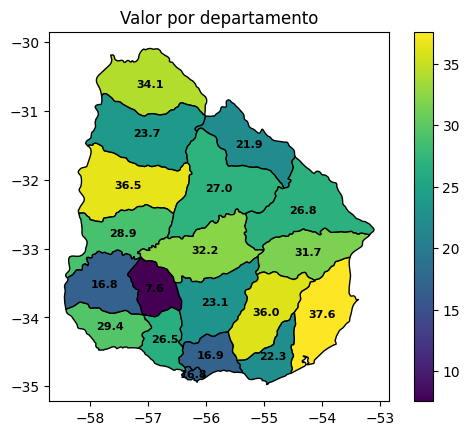

In [114]:
df_dptos = generar_estadistica_por_departamento(df_Mort2023)
generarMapaEstadisticaDepartamentos(df_dptos)

In [115]:
df_features_sin_dup

,ID IAE,Sexo,Pais_origen,Fechanacimiento,MetodoIAEMasFrecuente,MetodoIAEPrevio,IAEprevio,EnTratamiento,TipoTratamiento,PrestadorRecod,TipoPrestadorIAE,Fecha_registro,Fecha_IAE,Mort2023,Numero_intentos,Grupo_edad,IAEprevio_corregido
0,8,Femenino,URUGUAY,1976-10-29,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,COMERI,Privada,2023-09-03 16:18:44,2023-09-02,NaN,1,47.5,SI
1,21,Masculino,URUGUAY,1972-04-08,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP,Privada,2023-02-02 11:28:27,2023-01-31,NaN,2,52.5,SI
2,30,Femenino,URUGUAY,2003-09-29,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,CRAMI IAMPP,Privada,2023-10-02 22:57:00,2023-10-02,NaN,1,22.5,SI
3,38,Masculino,URUGUAY,1975-06-02,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en clínica privada,AMSJ IAMPP - ASOCIACION MEDICA DE SAN JOSE IAMPP,Privada,2023-10-23 14:46:00,2023-10-11,NaN,1,47.5,SI
4,51,Femenino,URUGUAY,2002-09-06,Lesiones autoinfligidas,Lesiones autoinfligidas,SI,SI,Tratamiento en el prestador habitual,CRAMI IAMPP,Privada,2023-08-28 19:06:59,2023-08-26,NaN,1,22.5,SI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4269,5969,Femenino,URUGUAY,1993-12-12,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,Publica,2024-03-06 14:16:00,2023-08-29,NaN,1,27.5,SI
4270,5970,Femenino,URUGUAY,1985-03-23,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,Publica,2024-03-06 14:21:00,2023-08-19,NaN,1,37.5,SI
4271,5971,Femenino,URUGUAY,1998-03-04,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS / DIRECCION NACION...,Publica,2024-03-06 14:22:00,2023-08-11,NaN,1,27.5,SI
4272,5972,Masculino,URUGUAY,1998-10-04,Ingesta de Medicamentos,Ingesta de Medicamentos,SI,SI,Tratamiento en el prestador habitual,ASSE - HOSPITAL DE CLINICAS,Publica,2024-03-06 14:22:00,2023-08-11,NaN,1,22.5,SI


In [116]:
# Este data frame (77 casos) incluye personas que tuvieron IAE y además murieron en 2023 (por suicidio u otras causas)
data1_X = df_features_sin_dup[["Grupo_edad","Sexo", "IAEprevio_corregido","EnTratamiento", "MetodoIAEPrevio"]]
data1_X["Sexo"]=data1_X["Sexo"]=='Masculino'
data1_y = df_features_sin_dup["Mort2023"]==1
print(np.sum(data1_y==1))
print(data1_X.shape)

77
(4274, 5)


/tmp/ipykernel_209947/3222996972.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1_X["Sexo"]=data1_X["Sexo"]=='Masculino'


In [117]:
df_Mort2023.keys()

Index(['Sexo', 'PaisdeNacimiento', 'Prestador', 'fechaDeNacimiento',
       'EDADAnios', 'EstadoCivil', 'Etnia2', 'MayorNivelAlcanzado2',
       'DepartamentodeResidencia', 'localidad_de_residencia',
       'zona_residencia', 'LUGARDEL', 'fechaDeDefuncion', 'Motivoexterno',
       'EnfermedadCausanteCIE10', 'ID', 'Tipo prestador', 'grupo edades'],
      dtype='object')

In [118]:
df_Mort2023.head()

,Sexo,PaisdeNacimiento,Prestador,fechaDeNacimiento,EDADAnios,EstadoCivil,Etnia2,MayorNivelAlcanzado2,DepartamentodeResidencia,localidad_de_residencia,zona_residencia,LUGARDEL,fechaDeDefuncion,Motivoexterno,EnfermedadCausanteCIE10,ID,Tipo prestador,grupo edades
0,Femenino,Uruguay,Gremca,15/2/1949,74,Divorciado/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,28/7/2023,No corresponde,A020,NaN,Privada,72.5
1,Masculino,Uruguay,Amecom,5/8/1983,39,Soltero/a,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,25/2/2023,No corresponde,A021,NaN,Privada,37.5
2,Masculino,No indicado,ASSE - Administración de Servicios de Salud de...,19/11/1927,95,No indicado,Blanca,No indicado,Maldonado,MALDONADO,NaN,Centro Asistencial,6/2/2023,No corresponde,A044,NaN,Publica,97.5
3,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,29/1/1936,86,Casado/a,No indicado,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,15/1/2023,No corresponde,A047,NaN,Privada,87.5
4,Masculino,Uruguay,Asoc. Española 1a De Socorros Mutuos,12/7/1941,82,Viudo/a,Blanca,No indicado,Montevideo,MONTEVIDEO,NaN,Centro Asistencial,17/7/2023,No corresponde,A047,NaN,Privada,82.5


In [119]:
#motivo_externo_dic = df_Mort2023.set_index("ID")["Motivoexterno"].to_dict()
#motivo_externo_dic = dict(zip(df_Mort2023["ID"], df_Mort2023["Motivoexterno"]))

motivo_externo_dic = (
    df_Mort2023.dropna(subset=["ID", "Motivoexterno"])  # elimina filas con NaN en esas columnas
      .set_index("ID")["Motivoexterno"]
      .to_dict()
)


np.unique(motivo_externo_dic.keys())

array([dict_keys([53.0, 2453.0, 1261.0, 3341.0, 118.0, 946.0, 1171.0, 1854.0, 3746.0, 969.0, 2719.0, 2386.0, 3361.0, 1141.0, 935.0, 456.0, 2646.0, 655.0, 3263.0, 1328.0, 448.0, 2812.0, 463.0, 861.0, 125.0, 296.0, 1144.0, 2262.0, 4915.0, 677.0, 2168.0, 3277.0, 3635.0, 2972.0, 1353.0, 1547.0, 385.0, 1762.0, 2779.0, 258.0, 2863.0, 4118.0, 434.0, 1646.0, 1392.0, 1486.0, 1289.0, 2795.0, 4437.0, 2612.0, 2772.0, 2243.0, 2185.0, 117.0, 3495.0, 77.0, 1849.0, 3677.0, 4333.0, 255.0, 1467.0, 2737.0, 4553.0, 73.0, 2927.0, 1778.0, 4269.0, 499.0, 4257.0, 4295.0, 4689.0, 1642.0, 381.0, 2566.0, 2376.0, 387.0, 2528.0])],
      dtype=object)

In [120]:
motivo_externo_dic.keys()

dict_keys([53.0, 2453.0, 1261.0, 3341.0, 118.0, 946.0, 1171.0, 1854.0, 3746.0, 969.0, 2719.0, 2386.0, 3361.0, 1141.0, 935.0, 456.0, 2646.0, 655.0, 3263.0, 1328.0, 448.0, 2812.0, 463.0, 861.0, 125.0, 296.0, 1144.0, 2262.0, 4915.0, 677.0, 2168.0, 3277.0, 3635.0, 2972.0, 1353.0, 1547.0, 385.0, 1762.0, 2779.0, 258.0, 2863.0, 4118.0, 434.0, 1646.0, 1392.0, 1486.0, 1289.0, 2795.0, 4437.0, 2612.0, 2772.0, 2243.0, 2185.0, 117.0, 3495.0, 77.0, 1849.0, 3677.0, 4333.0, 255.0, 1467.0, 2737.0, 4553.0, 73.0, 2927.0, 1778.0, 4269.0, 499.0, 4257.0, 4295.0, 4689.0, 1642.0, 381.0, 2566.0, 2376.0, 387.0, 2528.0])

In [121]:
motivo_externo_dic.keys()

dict_keys([53.0, 2453.0, 1261.0, 3341.0, 118.0, 946.0, 1171.0, 1854.0, 3746.0, 969.0, 2719.0, 2386.0, 3361.0, 1141.0, 935.0, 456.0, 2646.0, 655.0, 3263.0, 1328.0, 448.0, 2812.0, 463.0, 861.0, 125.0, 296.0, 1144.0, 2262.0, 4915.0, 677.0, 2168.0, 3277.0, 3635.0, 2972.0, 1353.0, 1547.0, 385.0, 1762.0, 2779.0, 258.0, 2863.0, 4118.0, 434.0, 1646.0, 1392.0, 1486.0, 1289.0, 2795.0, 4437.0, 2612.0, 2772.0, 2243.0, 2185.0, 117.0, 3495.0, 77.0, 1849.0, 3677.0, 4333.0, 255.0, 1467.0, 2737.0, 4553.0, 73.0, 2927.0, 1778.0, 4269.0, 499.0, 4257.0, 4295.0, 4689.0, 1642.0, 381.0, 2566.0, 2376.0, 387.0, 2528.0])

In [122]:
data2_X = df_features_sin_dup[["Grupo_edad","Sexo", "IAEprevio_corregido","EnTratamiento", "MetodoIAEPrevio"]]
data2_X["Sexo"]=data2_X["Sexo"]=='Masculino'
data2_y = df_features_sin_dup["ID IAE"].map(motivo_externo_dic)
data2_y = data2_y=='Suicidio'
print(np.sum(data2_y==1))
print(data2_y.shape)

34
(4274,)


/tmp/ipykernel_209947/2135103276.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2_X["Sexo"]=data2_X["Sexo"]=='Masculino'


## Modelo con conjunto de datos 1

In [123]:
data1_X.describe()

,Grupo_edad,Sexo,IAEprevio_corregido,EnTratamiento,MetodoIAEPrevio
count,4274.0,4274,4274,4274,4274
unique,18.0,2,3,4,6
top,17.5,False,SI,SI,Ingesta de Medicamentos
freq,836.0,3062,2123,2939,3057


In [124]:
data1_X['EnTratamiento'].value_counts()

EnTratamiento
SI                                      2939
NO                                      1332
Sin dato                                   2
Tratamiento en el prestador habitual       1
Name: count, dtype: int64

In [125]:
data1_X['MetodoIAEPrevio'].value_counts()

MetodoIAEPrevio
Ingesta de Medicamentos    3057
Otros                       424
Lesiones autoinfligidas     391
Ahorcamiento o asfixia      384
Arma de fuego                17
otros                         1
Name: count, dtype: int64

In [217]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



def generate_preprocessing_pipeline():

    num_attribs = ["Grupo_edad"]
    cat_attribs = ["IAEprevio_corregido", "EnTratamiento","MetodoIAEPrevio"]

    num_pipeline = Pipeline([
    ("standardize", StandardScaler()),
    ])

    cat_pipeline = make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore"))


    preprocessing = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs)
        ], remainder='passthrough')
    
    return preprocessing


from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

def build_model_with_cv(preprocessing, classifier='LogisticRegression', cv=5, criteria='roc_auc', n_jobs=-1):
    """
    Construye un pipeline con preprocesamiento y optimización de hiperparámetros
    mediante validación cruzada, para distintos clasificadores.
    """

    # Modelos base
    classifiers = {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'RandomForest': RandomForestClassifier(),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'SVM': SVC(probability=True),
        'DecisionTree': DecisionTreeClassifier()
    }

    # Espacios de búsqueda razonables por modelo
    param_grids = {
        'LogisticRegression': {
            'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs']
        },
        'RandomForest': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        },
        'XGBoost': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5, 8],
            'classifier__learning_rate': [0.01, 0.1, 0.3]
        },
        'SVM': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        },
        'DecisionTree': {
            'classifier__max_depth': [3, 5, 10, None],
            'classifier__min_samples_split': [2, 5, 10]
        }
    }

    # Verificación
    if classifier not in classifiers:
        raise ValueError(f"Clasificador '{classifier}' no soportado. Opciones: {list(classifiers.keys())}")

    # Construcción del pipeline
    base_pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("classifier", classifiers[classifier])
    ])

    # Configurar búsqueda con CV
    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grids[classifier],
        cv=cv,
        n_jobs=n_jobs,
        scoring=criteria,
        return_train_score=False
    )

    return grid_search


preprocessing = generate_preprocessing_pipeline()
gs_pipeline = build_model_with_cv(preprocessing, classifier='LogisticRegression', criteria='accuracy')
gs_pipeline.fit(data1_X, data1_y.values)

/home/carbajal/miniconda3/envs/taa2025-py312/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('standardize',
                                                                                          StandardScaler())]),
                                                                         ['Grupo_edad']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['IAEprevio_corregido',
                                                                          'EnTratamiento',
                                                                          'MetodoIAEPrevio'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='accuracy')

In [218]:
resultados = pd.DataFrame(gs_pipeline.cv_results_)
resultados = resultados.sort_values('mean_test_score', ascending=False)

# Mostrar columnas relevantes
display(resultados[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']])

,params,mean_test_score,std_test_score,rank_test_score
4,"{'classifier__C': 10, 'classifier__penalty': '...",0.982686,0.000871,1
5,"{'classifier__C': 100, 'classifier__penalty': ...",0.982686,0.000871,1
3,"{'classifier__C': 1, 'classifier__penalty': 'l...",0.982453,0.001275,3
0,"{'classifier__C': 0.001, 'classifier__penalty'...",0.981984,0.000570,4
1,"{'classifier__C': 0.01, 'classifier__penalty':...",0.981984,0.000570,4
2,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.981984,0.000570,4


In [219]:
lr_pipeline.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_classifier__C', 'param_classifier__penalty', 'param_classifier__solver', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [220]:
gs_pipeline.cv_results_['std_test_score']

array([0.00056967, 0.00056967, 0.00056967, 0.00127472, 0.00087117,
       0.00087117])

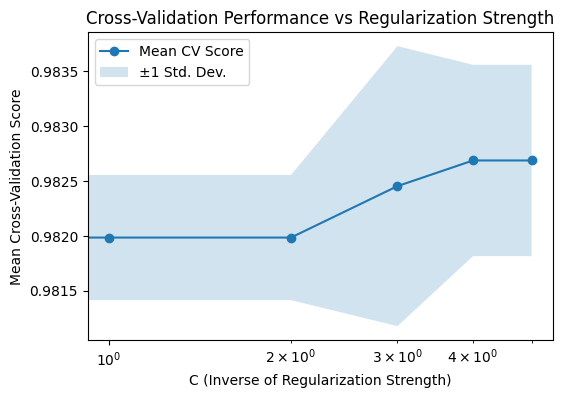

In [221]:
lr_clf = gs_pipeline.best_estimator_

gs_pipeline.cv_results_

def show_cross_validation_results(gs_pipeline):

    #for clase, scores in classifier.scores_.items():
    #    print(f"Clase {clase}: shape {scores.shape}")  # (n_folds, n_Cs)

    #scores = list(classifier.scores_.values())[0]  # si es binario, tomamos la clase positiva
    #mean_scores = np.mean(scores, axis=0)
    #std_scores = np.std(scores, axis=0)

    import matplotlib.pyplot as plt
    mean_scores = gs_pipeline.cv_results_['mean_test_score']
    std_scores = gs_pipeline.cv_results_['std_test_score']

    plt.figure(figsize=(6,4))
    plt.semilogx( mean_scores, marker='o', label='Mean CV Score')
    plt.fill_between(
        np.arange(len(mean_scores)),
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.2,
        label='±1 Std. Dev.'
    )
    plt.xlabel("C (Inverse of Regularization Strength)")
    plt.ylabel("Mean Cross-Validation Score")
    plt.title("Cross-Validation Performance vs Regularization Strength")
    plt.legend()
    plt.show()


show_cross_validation_results(gs_pipeline)



In [222]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib import pyplot as plt


def show_cv_confusion_matrix(cv_scores, y, threshold=0.5):


    # Calcular la matriz de confusión
    cm = confusion_matrix(y, cv_scores>threshold)

    # Mostrarla
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Matriz de confusión (validación cruzada), th={threshold:.02f}')
    plt.savefig('CV_conf_matrix.png')
    plt.show()

def show_cv_precision_recall(cv_scores, y):
    
    precision, recall, _ = precision_recall_curve(y, cv_scores)
    ap = average_precision_score(y, cv_scores)

    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Cross-validated Precision–Recall Curve")
    plt.legend()
    plt.grid(True, ls='--', alpha=0.6)
    plt.savefig('CV_PR.png')
    plt.show()


def show_cv_roc(cv_scores, y):

    #y_score = model1_pipeline.predict_proba(data1_X)[:, 1]  # probabilidad de la clase positiva
    fpr, tpr, _ = roc_curve(y, cv_scores)
    auc = roc_auc_score(y, cv_scores)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Cross Validated ROC curve")
    plt.legend()
    plt.savefig('Cross Validated ROC curve')
    plt.show()


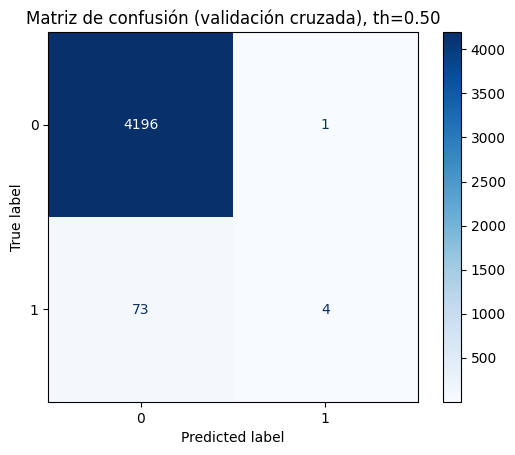

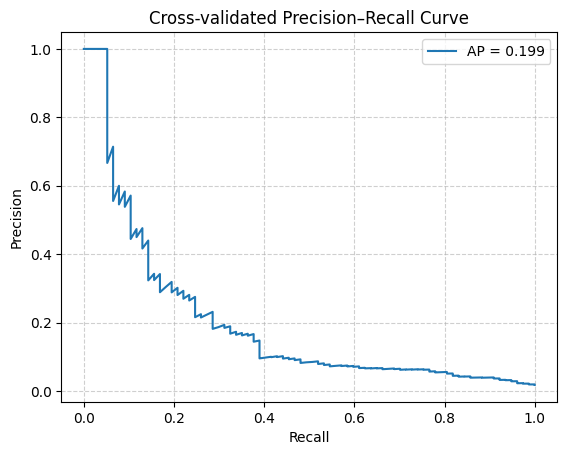

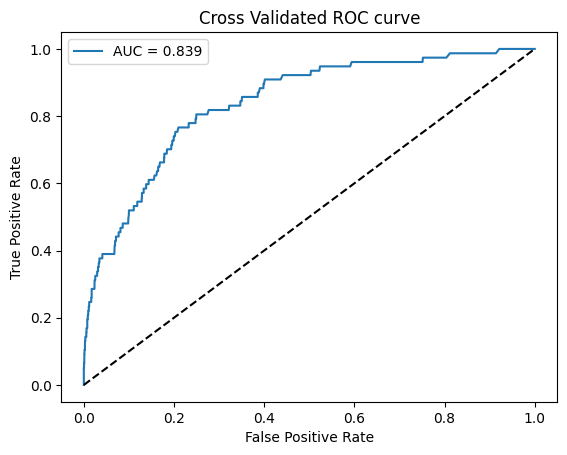

In [223]:
cv_scores = cross_val_predict(gs_pipeline, data1_X, data1_y,
                                cv=5, method='predict_proba')[:, 1]

show_cv_confusion_matrix(cv_scores, data1_y)
show_cv_precision_recall(cv_scores, data1_y)
show_cv_roc(cv_scores,data1_y)

In [224]:
gs_pipeline.best_estimator_.score(data1_X, data1_y)

0.9829199812821713

In [226]:
gs_pipeline.score(data1_X, data1_y)

0.9829199812821713

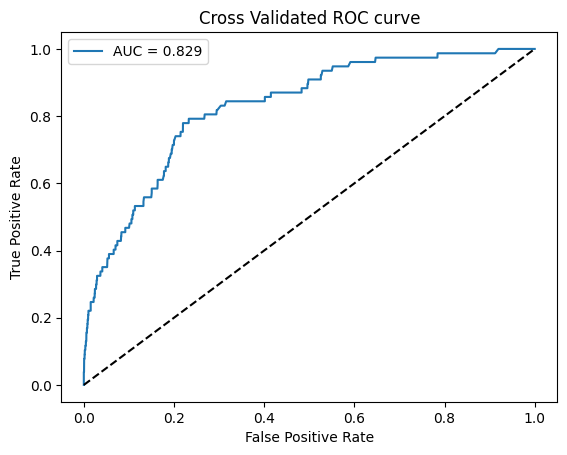

In [138]:
import numpy as np
odds_ratios = np.exp(model1_pipeline['classifier'].coef_)


In [139]:
odds_ratios

array([[2.78908488, 0.94742373, 1.55646614, 0.66262677, 0.90411981,
        1.08701694, 0.99563803, 0.99859443, 0.86779139, 5.70567065,
        0.45942872, 0.5634924 , 0.76531856, 0.99605297, 3.11729653]])

In [140]:
params = model1_pipeline['classifier'].get_params()
params

{'Cs': 10,
 'class_weight': None,
 'cv': 5,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'l1_ratios': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'refit': True,
 'scoring': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0}

In [141]:
model1_pipeline['preprocessing'].get_feature_names_out()

array(['num__Grupo_edad', 'cat__IAEprevio_corregido_NO',
       'cat__IAEprevio_corregido_NO SE INDICA',
       'cat__IAEprevio_corregido_SI', 'cat__EnTratamiento_NO',
       'cat__EnTratamiento_SI', 'cat__EnTratamiento_Sin dato',
       'cat__EnTratamiento_Tratamiento en el prestador habitual',
       'cat__MetodoIAEPrevio_Ahorcamiento o asfixia',
       'cat__MetodoIAEPrevio_Arma de fuego',
       'cat__MetodoIAEPrevio_Ingesta de Medicamentos',
       'cat__MetodoIAEPrevio_Lesiones autoinfligidas',
       'cat__MetodoIAEPrevio_Otros', 'cat__MetodoIAEPrevio_otros',
       'remainder__Sexo'], dtype=object)

In [142]:
model1_pipeline['classifier'].coef_

array([[ 1.02571354e+00, -5.40088390e-02,  4.42417958e-01,
        -4.11543387e-01, -1.00793395e-01,  8.34371940e-02,
        -4.37151130e-03, -1.40655522e-03, -1.41803923e-01,
         1.74146053e+00, -7.77771483e-01, -5.73601441e-01,
        -2.67463108e-01, -3.95484405e-03,  1.13696613e+00]])

In [143]:
coef_df = pd.DataFrame(
    model1_pipeline['classifier'].coef_.T,  # transponemos para alinear cada feature
    index=model1_pipeline['preprocessing'].get_feature_names_out(),
    #columns=model1_pipeline['classifier'].classes_  # una columna por clase
)

In [144]:
coef_df

,0
num__Grupo_edad,1.025714
cat__IAEprevio_corregido_NO,-0.054009
cat__IAEprevio_corregido_NO SE INDICA,0.442418
cat__IAEprevio_corregido_SI,-0.411543
cat__EnTratamiento_NO,-0.100793
cat__EnTratamiento_SI,0.083437
cat__EnTratamiento_Sin dato,-0.004372
cat__EnTratamiento_Tratamiento en el prestador habitual,-0.001407
cat__MetodoIAEPrevio_Ahorcamiento o asfixia,-0.141804
cat__MetodoIAEPrevio_Arma de fuego,1.741461


In [145]:
odds_ratios_df = pd.DataFrame(
    odds_ratios.T,  # transponemos para alinear cada feature
    index=model1_pipeline['preprocessing'].get_feature_names_out(),
    #columns=model1_pipeline['classifier'].classes_  # una columna por clase
)

In [146]:
odds_ratios_df

,0
num__Grupo_edad,2.789085
cat__IAEprevio_corregido_NO,0.947424
cat__IAEprevio_corregido_NO SE INDICA,1.556466
cat__IAEprevio_corregido_SI,0.662627
cat__EnTratamiento_NO,0.904120
cat__EnTratamiento_SI,1.087017
cat__EnTratamiento_Sin dato,0.995638
cat__EnTratamiento_Tratamiento en el prestador habitual,0.998594
cat__MetodoIAEPrevio_Ahorcamiento o asfixia,0.867791
cat__MetodoIAEPrevio_Arma de fuego,5.705671


In [295]:
df_features_sin_dup["IAEprevio_corregido"].value_counts()

IAEprevio_corregido
SI              2123
NO              1482
NO SE INDICA     669
Name: count, dtype: int64

In [282]:
data1_y.unique()

array([False,  True])

In [283]:
data1_X=data1[["Grupo_edad","Sexo", "IAEprevio_corregido","EnTratamiento", "MetodoIAEMasFrecuente"]]
data1_y = data1['Motivo_externo']=='Suicidio'

NameError: name 'data1' is not defined

Motivo_externo
True     33
False    29
Name: count, dtype: int64

In [99]:
df_IAE2023['PrestadorRecod'].value_counts()

PrestadorRecod
MEDICA URUGUAYA MUCAM                         355
CASMU                                         240
UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA    231
CIRCULO CATOLICO DE OBREROS DEL URUGUAY       196
ASSE - MALDONADO                              162
                                             ... 
ASSE - PAYSANDU QUEBRACHO                       1
ASSE - FRANCISCO SOCA                           1
MUCAM - ASSE - SD                               1
PARTICULAR                                      1
ASSE - DURAZNO SARANDI DEL YI                   1
Name: count, Length: 426, dtype: int64

In [100]:
df_Mort2023['Motivoexterno'].value_counts()

Motivoexterno
No corresponde    31951
Accidente          1084
Suicidio            763
Homicidio           391
Se desconoce        207
Otro                  3
Name: count, dtype: int64